# AlexNet Benchmark

use PY310, py311 not support torch.compile, py39 not support libnvrtc.so compatibility

In [1]:
model_name = "ResNet34"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll


In [2]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Prepare

In [3]:
#recompute, storeall = [
#    ragdoll.compile(x, "gpu", "input", "codegen", benchmark=True) for x in ["recompute.mlir", "storeall.mlir"]
#]
#recompute = ragdoll.compile("recompute.mlir", "gpu", "input", "codegen", benchmark=True)
#storeall = ragdoll.compile("storeall.mlir", "gpu", "input", "codegen", benchmark=True)
!iree-compile recompute.mlir \
-o recompute.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86

!iree-compile storeall.mlir \
-o storeall.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86
recompute = "recompute.vmfb"
storeall = "storeall.vmfb"

In [4]:
def load_executable(fb_file):
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo

#recompute_fb, storeall_fb = [
#    load_executable(x) for x in [recompute, storeall]
#]
recompute_fb = load_executable("recompute.vmfb")
storeall_fb = load_executable("storeall.vmfb")

## Experimental

In [5]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

model = models.resnet34().train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model_dynamo = torch.compile(model, backend="inductor")

device = torch.device("cuda:0")
image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)
model_native = model.to(device)

output_native = model_native(image)
output_dynamo = model_dynamo(image)
grad = torch.randn_like(output_native)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()

df = pd.DataFrame()

### PyTorch (Baseline)

In [6]:
baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output_dynamo, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-dynamo-gpu-forward:  [3.085845150053501, 3.066704608500004, 3.0583780916298138, 3.0571845195749225, 3.0631653635817417, 3.0565698466756763, 3.0562210389796425, 3.055608064374503, 3.05236760965165, 3.048754297196865, 3.0519380508100284]
3.0593396946389406
torch-dynamo-gpu-backward:  [4.543725127244697, 3.4311926540206463, 3.4308395731975048, 3.4317920422729324, 3.430718775181209, 3.4311932566411354, 3.451373482889989, 3.4521891571143093, 3.4508372054380527, 3.452108405968722, 3.4522333127610825]
3.5416548175209344
       time      pass          item
0  3.059340   Forward  Torch Dynamo
0  3.541655  Backward  Torch Dynamo
0  6.600995      Full  Torch Dynamo


### Nabla without Optim

In [7]:
f1 = []
for i in range(11):
  f1 += [timeit("recompute_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    recompute,
    "forward",
    [(1, 3, 224, 224)], 
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)


print('ragdoll-opt1-gpu-forward in benchmark: ', f2)

f2 = np.mean(f2)

print(f1)
print(f2)

ragdoll-opt1-gpu-forward in timeit:  [0.18009300234124942, 0.1640962847672841, 0.1642008246306111, 0.16424214029136827, 0.16405639567357652, 0.1640660156879355, 0.16409478150308132, 0.16406669884043582, 0.16420644214924643, 0.16400128493414207, 0.16406099366791108]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [0.109, 0.109, 0.109, 0.109, 0.109, 0.109, 0.109, 0.109, 0.109, 0.109, 0.109]
0.16556226040789468
0.109


In [8]:
b1 = []
for i in range(11):
    b1 += [timeit("recompute_fb.dforward(grad_np)") /  17.0]
print('ragdoll-opt1-gpu-backward in timeit: ', b1)
# TODO(albert): unresolved value error
"""
b2 = ragdoll_model_benchmark(
    recompute,
    "dforward",
    [(1, 1000)],
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)
print(b2)
"""
df = pd.concat([df, get_dataframe(f2, np.mean(b1), "Nabla-opt1")])
print(df)

ragdoll-opt1-gpu-backward in timeit:  [0.3545013541246162, 0.3512559414786451, 0.35116291714503484, 0.3512197721968679, 0.3511903221335481, 0.351094721323427, 0.35127066404503937, 0.35112854531582666, 0.3511261288076639, 0.35111190751194954, 0.35121838726541577]
       time      pass          item
0  3.059340   Forward  Torch Dynamo
0  3.541655  Backward  Torch Dynamo
0  6.600995      Full  Torch Dynamo
0  0.109000   Forward    Nabla-opt1
0  0.351480  Backward    Nabla-opt1
0  0.460480      Full    Nabla-opt1


### Nabla with Optim

In [9]:
f1 = []
for i in range(11):
  f1 += [timeit("storeall_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    storeall,
    "forward",
    [(1, 3, 224, 224)], 
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)
print('ragdoll-opt1-gpu-forward in benchmark: ', f2)

b1 = []
for i in range(11):
    b1 += [timeit("storeall_fb.dforward(grad_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', b1)
b1 = np.mean(b1)


df = pd.concat([df, get_dataframe(np.mean(f2), b1, "Nabla-opt2")])
print(df)

ragdoll-opt1-gpu-forward in timeit:  [0.21680593600167947, 0.2163567952811718, 0.2164747445460628, 0.21645556751857786, 0.21655979018439264, 0.21641618572175503, 0.2165120401803185, 0.2164193631752449, 0.2164397542090977, 0.2164690985399134, 0.2164205240414423]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [0.183, 0.183, 0.183, 0.183, 0.183, 0.183, 0.183, 0.183, 0.183, 0.183, 0.183]
ragdoll-opt1-gpu-forward in timeit:  [0.35496219992637634, 0.35289862467085614, 0.3530662205508527, 0.3528762937468641, 0.3528897190356956, 0.35284170442644286, 0.3528251959120526, 0.3529231951517217, 0.35280466956250806, 0.35291872699471083, 0.35288496326436014]
       time      pass          item
0  3.059340   Forward  Torch Dynamo
0  3.541655  Backward  Torch Dynamo
0  6.600995      Full  Torch Dynamo
0  0.109000   Forward    Nabla-opt1
0  0.351480  Backward    Nabla-opt1
0  0.460480      Full    Nabla-opt1
0  0.183000   Forward    Nabla-opt2
0  0.353081  Backward    Nabla-

In [10]:
df.style.hide(axis="index")

time,pass,item
3.059340,Forward,Torch Dynamo
3.541655,Backward,Torch Dynamo
6.600995,Full,Torch Dynamo
0.109000,Forward,Nabla-opt1
0.351480,Backward,Nabla-opt1
0.460480,Full,Nabla-opt1
0.183000,Forward,Nabla-opt2
0.353081,Backward,Nabla-opt2
0.536081,Full,Nabla-opt2


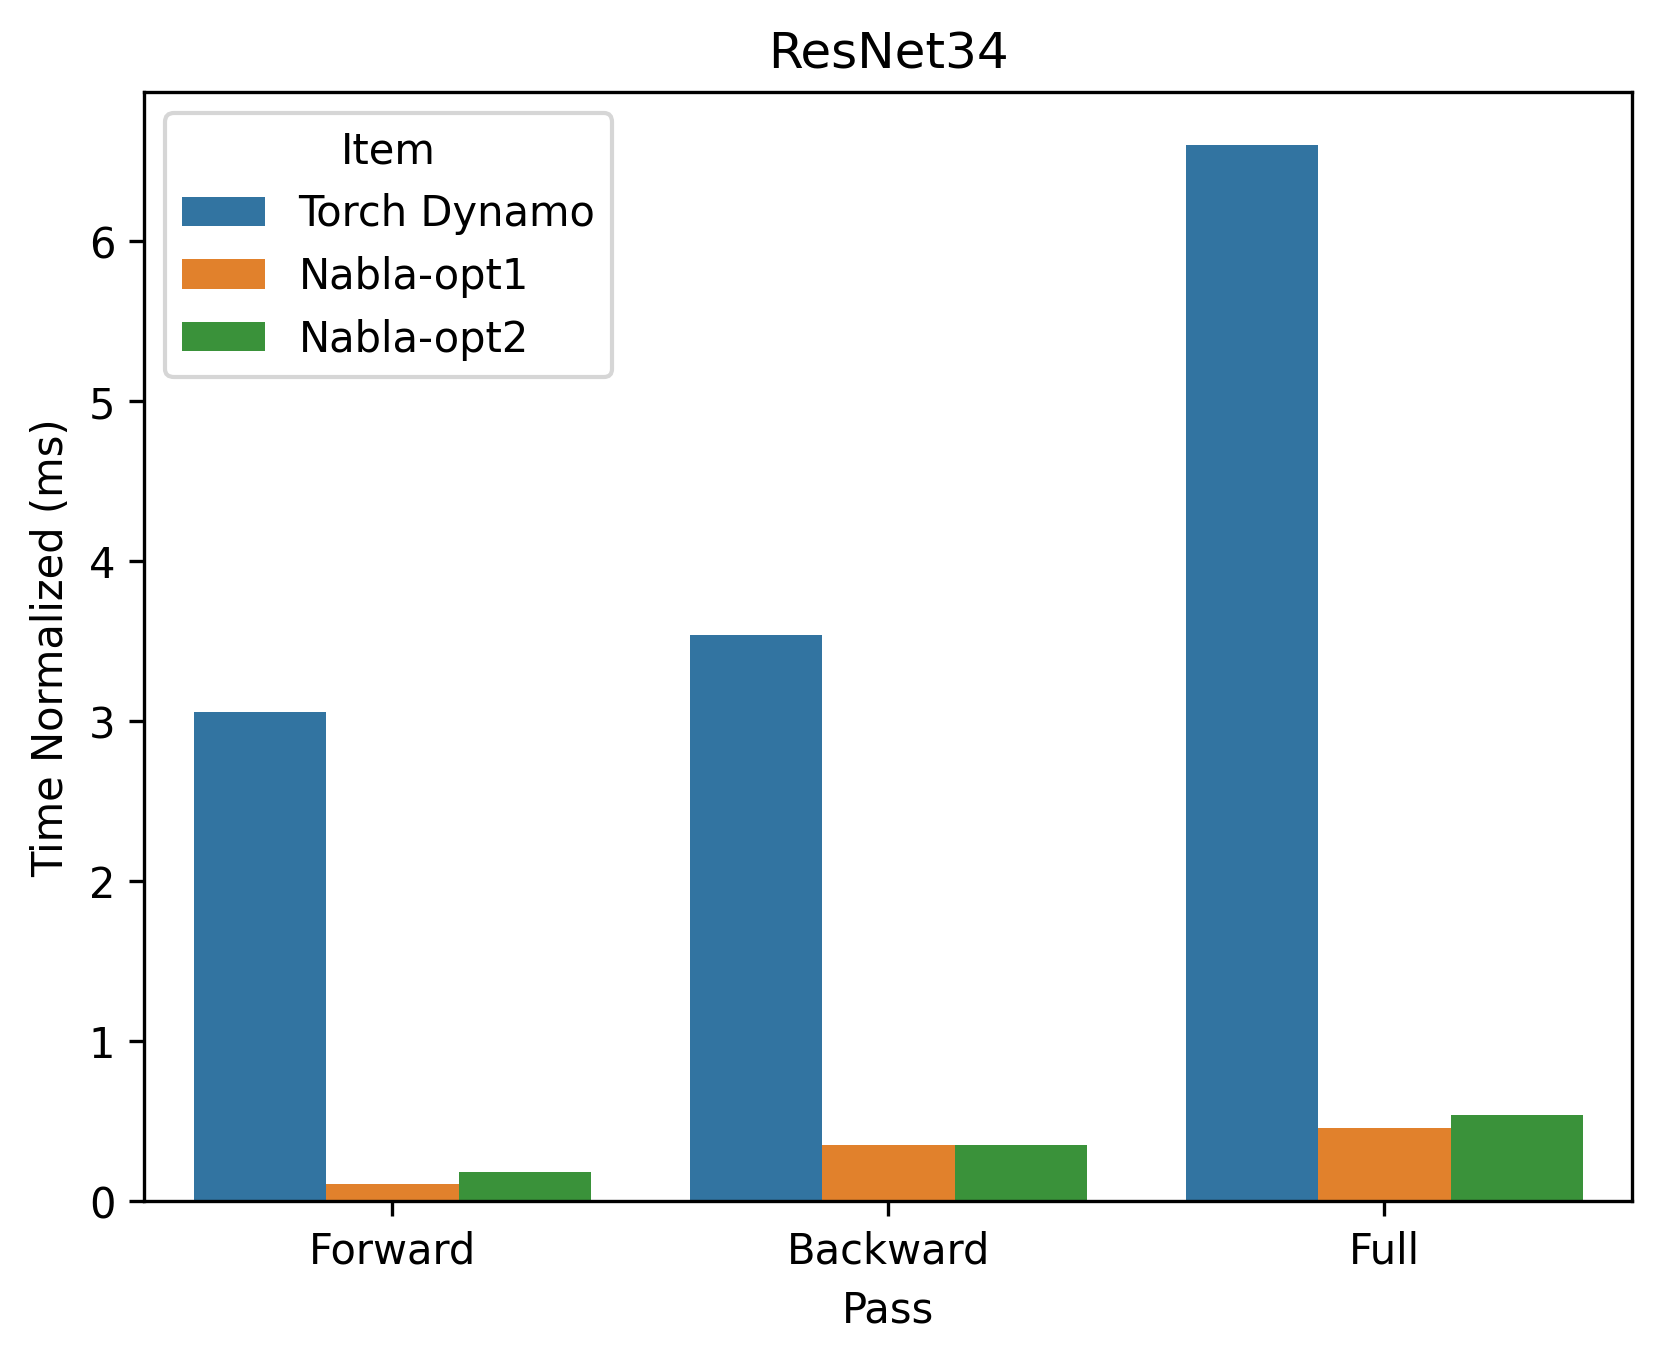

In [11]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [12]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,3.05934,Forward,Torch Dynamo,1.000000
0,0.10900,Forward,Nabla-opt1,28.067337
0,0.18300,Forward,Nabla-opt2,16.717703


In [13]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,3.541655,Backward,Torch Dynamo,1.000000
0,0.351480,Backward,Nabla-opt1,10.076403
0,0.353081,Backward,Nabla-opt2,10.030713


In [14]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,6.600995,Full,Torch Dynamo,1.000000
0,0.460480,Full,Nabla-opt1,14.335028
0,0.536081,Full,Nabla-opt2,12.313426


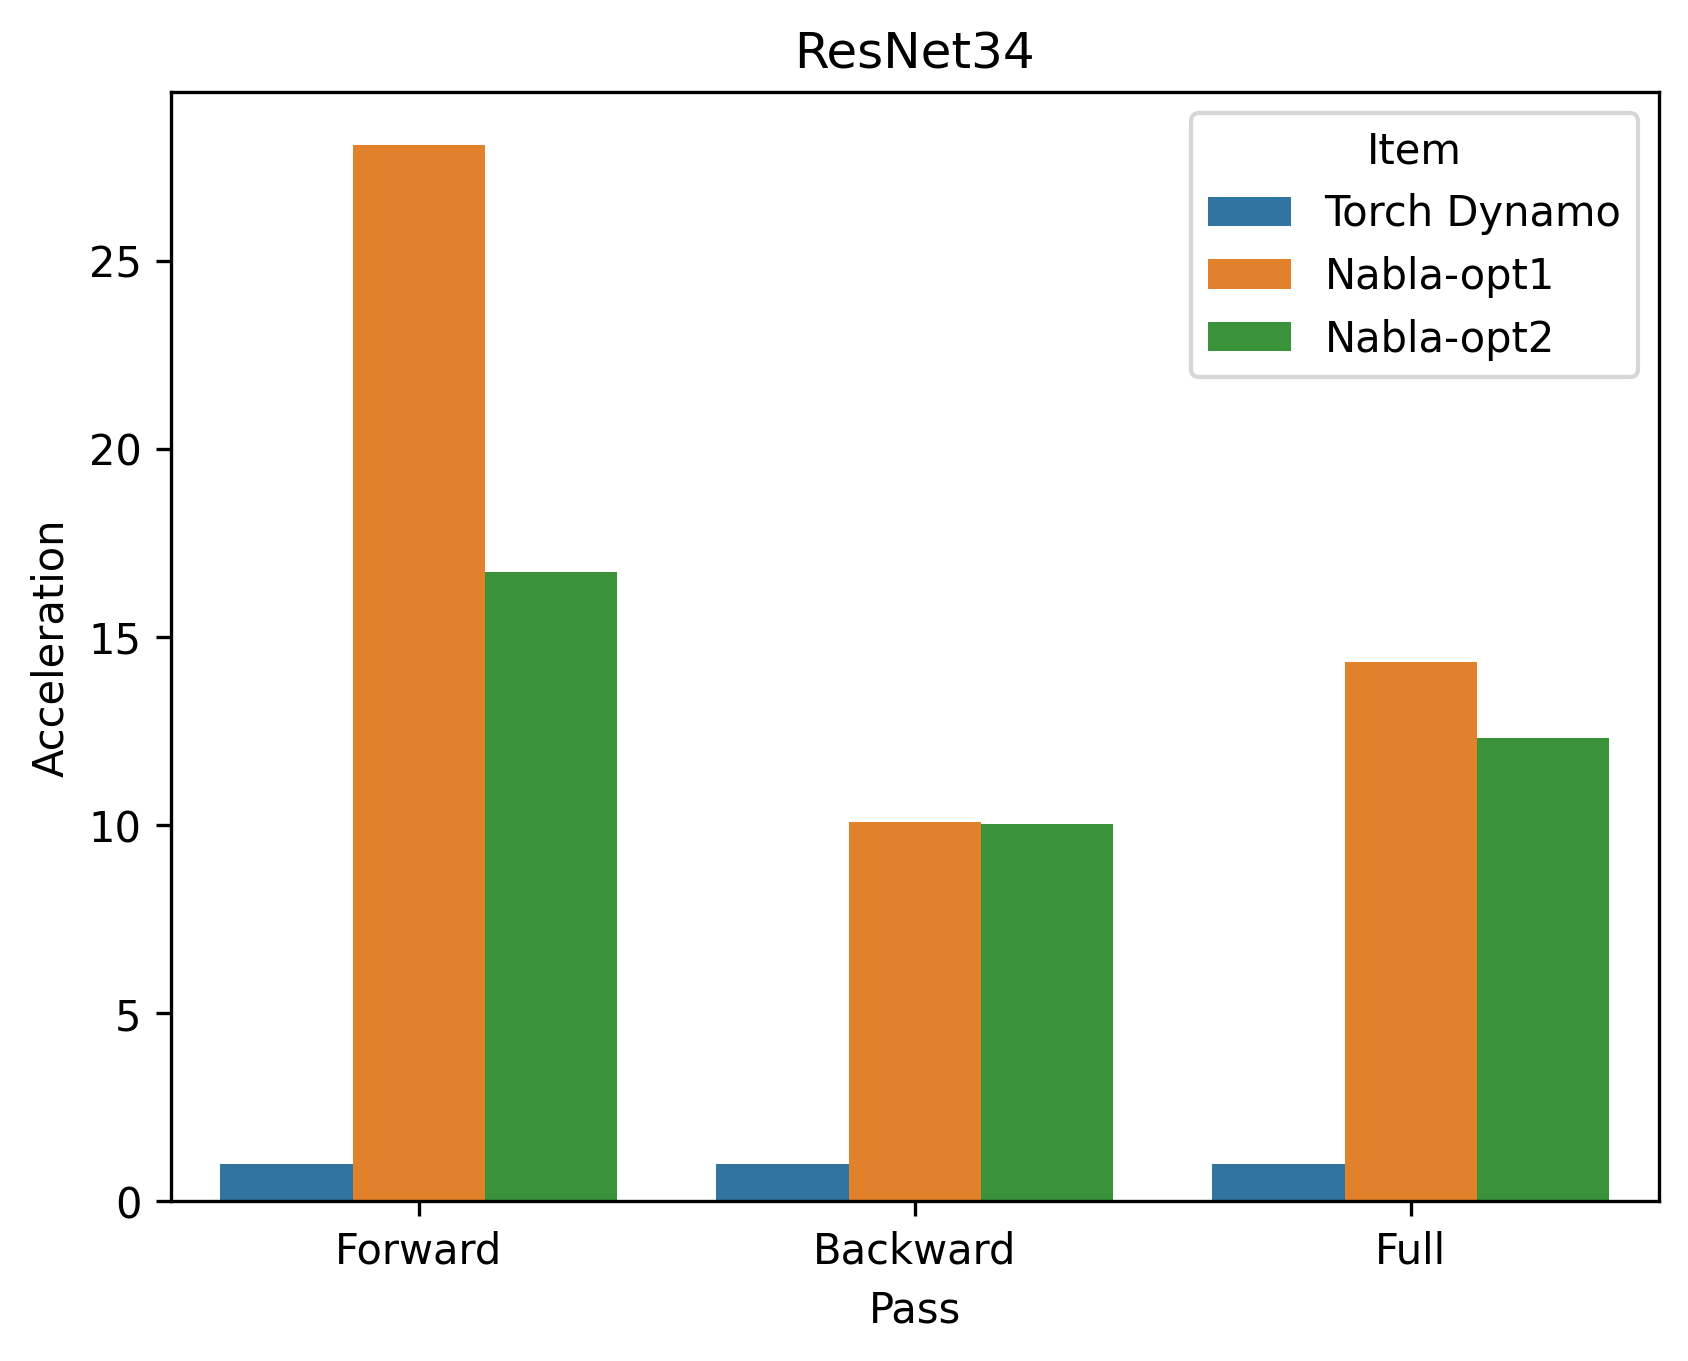

In [15]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")